In [1]:
#mount google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Cell 1: Setup and Load Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os

# Define project root (adjust if needed)
PROJECT_ROOT = '/content/drive/MyDrive/Advanced Machine Learning Project'

# Load config to get our target ticker dynamically
config_path = os.path.join(PROJECT_ROOT, 'config.json')
with open(config_path, 'r') as f:
    config = json.load(f)

target_ticker = config['data']['target_ticker']

# Load the saved CSVs
data_folder = os.path.join(PROJECT_ROOT, 'data')
returns_df = pd.read_csv(os.path.join(data_folder, 'log_returns.csv'), index_col=0, parse_dates=True)
targets_df = pd.read_csv(os.path.join(data_folder, 'binary_targets.csv'), index_col=0, parse_dates=True)

print(f"Loaded returns shape: {returns_df.shape}")
print(f"Target ticker for EDA: {target_ticker}")

Loaded returns shape: (2262, 19)
Target ticker for EDA: NVDA


/tmp/ipykernel_2574/1819719739.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_counts.index, y=target_counts.values, palette='viridis')


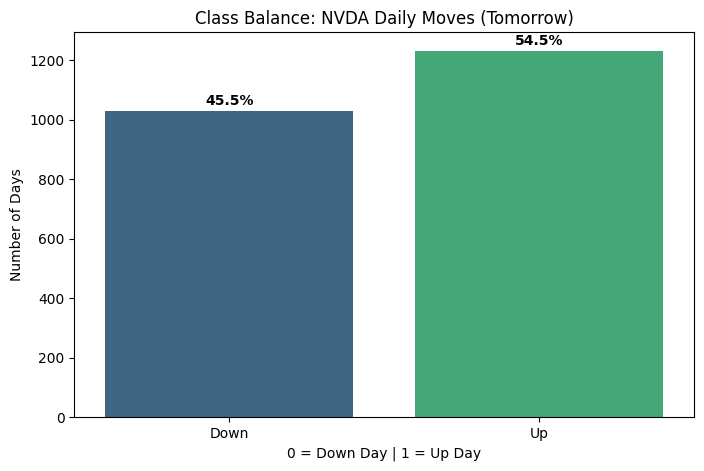

In [8]:
# Cell 2: Check Class Balance for the Target (CORRECTED)
plt.figure(figsize=(8, 5))

# FIX: Added .sort_index() to ensure 0 is first and 1 is second
target_counts = targets_df[target_ticker].value_counts().sort_index()

sns.barplot(x=target_counts.index, y=target_counts.values, palette='viridis')
plt.title(f'Class Balance: {target_ticker} Daily Moves (Tomorrow)')
plt.xlabel('0 = Down Day | 1 = Up Day')
plt.ylabel('Number of Days')
plt.xticks([0, 1], ['Down', 'Up'])

# Add percentage labels
for i, v in enumerate(target_counts.values):
    # This will now perfectly align the height (v) and the text with the correct bar
    plt.text(i, v + 20, f"{(v/target_counts.sum()*100):.1f}%", ha='center', fontweight='bold')

plt.show()

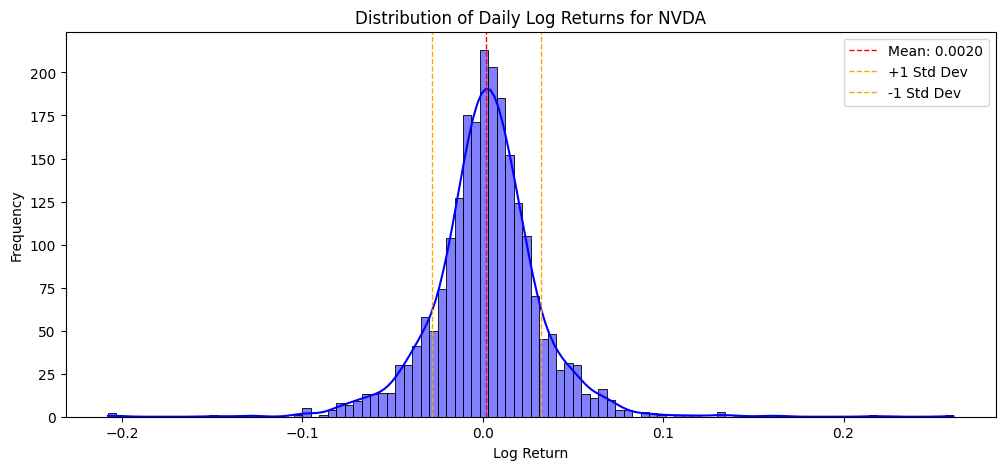

Annualized Volatility (assuming 252 trading days): 47.79%


In [5]:
# Cell 3: Distribution of Target Log Returns
plt.figure(figsize=(12, 5))

# Plot histogram of log returns
sns.histplot(returns_df[target_ticker], bins=100, kde=True, color='blue')
plt.title(f'Distribution of Daily Log Returns for {target_ticker}')
plt.xlabel('Log Return')
plt.ylabel('Frequency')

# Add lines for mean and standard deviations
mean_return = returns_df[target_ticker].mean()
std_return = returns_df[target_ticker].std()

plt.axvline(mean_return, color='red', linestyle='dashed', linewidth=1, label=f'Mean: {mean_return:.4f}')
plt.axvline(mean_return + std_return, color='orange', linestyle='dashed', linewidth=1, label='+1 Std Dev')
plt.axvline(mean_return - std_return, color='orange', linestyle='dashed', linewidth=1, label='-1 Std Dev')

plt.legend()
plt.show()

print(f"Annualized Volatility (assuming 252 trading days): {std_return * np.sqrt(252):.2%}")

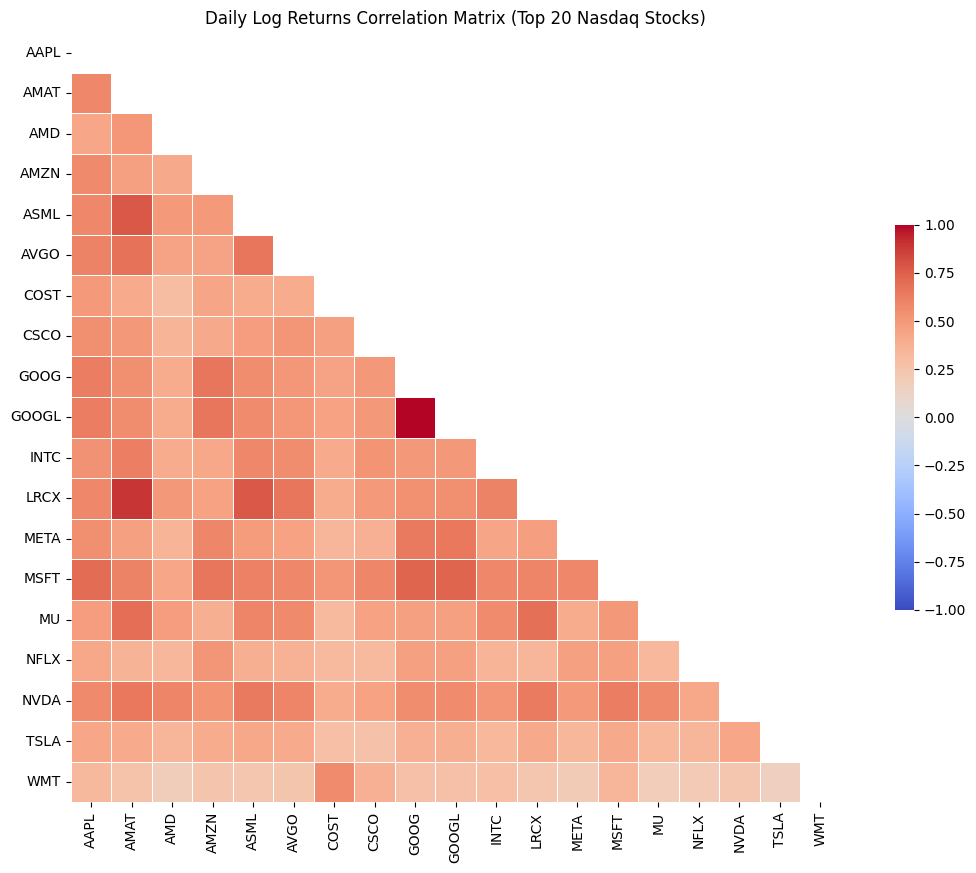

In [6]:
# Cell 4: Correlation Heatmap
plt.figure(figsize=(14, 10))

# Calculate the correlation matrix of the log returns
corr_matrix = returns_df.corr()

# Create a mask to hide the upper triangle (it's redundant)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', vmin=-1, vmax=1,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

plt.title('Daily Log Returns Correlation Matrix (Top 20 Nasdaq Stocks)')
plt.show()

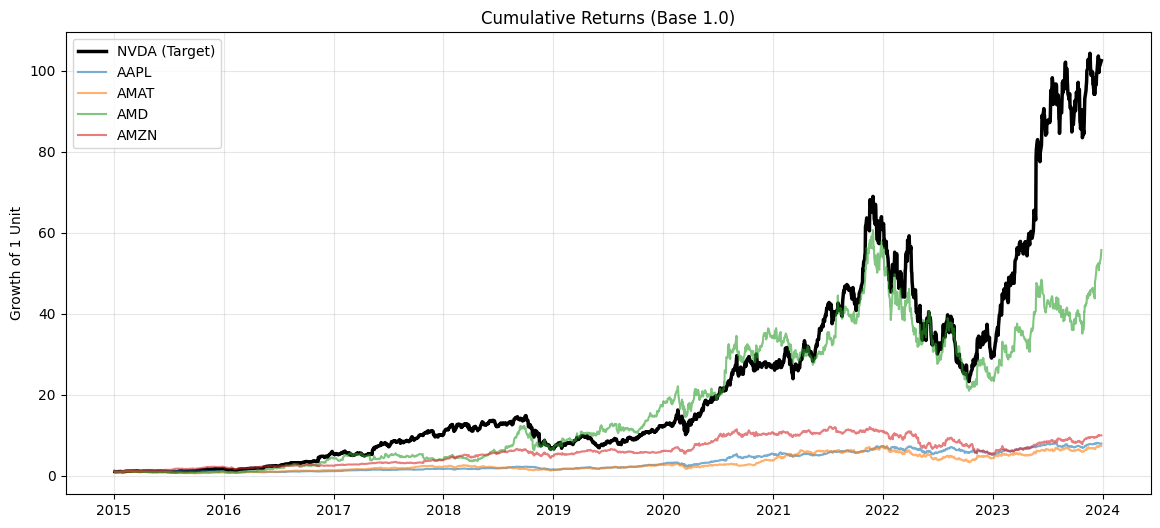

In [7]:
# Cell 5: Cumulative Returns
plt.figure(figsize=(14, 6))

# e^(sum of log returns) gives the cumulative multiplier
cumulative_returns = np.exp(returns_df.cumsum())

# Plot the target ticker in a bold color
plt.plot(cumulative_returns.index, cumulative_returns[target_ticker],
         label=f'{target_ticker} (Target)', color='black', linewidth=2.5)

# Plot a few other random tickers for comparison
sample_tickers = [t for t in returns_df.columns if t != target_ticker][:4]
for ticker in sample_tickers:
    plt.plot(cumulative_returns.index, cumulative_returns[ticker], label=ticker, alpha=0.6)

plt.title('Cumulative Returns (Base 1.0)')
plt.ylabel('Growth of 1 Unit')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()